# 03 — Exploratory Data Analysis
**Project:** Spatial–Temporal Analysis and Demand Forecasting of Ride-Hailing Mobility

**Purpose:** EDA on NYC TLC FHVHV trip data. Reads from PostgreSQL/TimescaleDB and produces charts covering temporal demand patterns, borough comparisons, trip characteristics, and weather correlation.

**Output:** Inline charts (saved to `outputs/eda/`) + printed findings.

**Tables used:** `hourly_demand`, `trip_events`, `taxi_zones`, `weather_data`

## 0 · Setup

In [5]:
# Install dependencies (Colab)
!pip install psycopg2-binary sqlalchemy pandas numpy matplotlib seaborn plotly -q

In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
BOROUGH_COLORS = {
    'Manhattan': '#2563EB',
    'Brooklyn':  '#16A34A',
    'Queens':    '#DC2626',
    'Bronx':     '#D97706',
    'Staten Island': '#7C3AED',
    'EWR': '#0891B2',
}

os.makedirs('outputs/eda', exist_ok=True)
print('Setup complete.')

Setup complete.


In [7]:
# ── Database connection ─────────────────────────────────────
PG_HOST = '8.tcp.ngrok.io'
PG_PORT = 12999
PG_DB   = 'rides'
PG_USER = 'rides'
PG_PASS = 'rides'

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}',
    pool_pre_ping=True,
)

with engine.connect() as conn:
    result = conn.execute(text('SELECT COUNT(*) FROM hourly_demand')).scalar()
    print(f'hourly_demand rows: {result:,}')
    result = conn.execute(text('SELECT COUNT(*) FROM trip_events')).scalar()
    print(f'trip_events rows:   {result:,}')

hourly_demand rows: 13,782
trip_events rows:   2,229,663


In [8]:
with engine.connect() as conn:
    conn.execute(text("TRUNCATE hourly_demand"))
    conn.execute(text("""
        INSERT INTO hourly_demand
            (time_bucket, zone_id, pickup_count, dropoff_count, avg_trip_miles, avg_trip_time)
        SELECT
            date_trunc('hour', pickup_datetime),
            pu_zone_id,
            COUNT(*),
            0,
            AVG(trip_miles),
            AVG(trip_time_min)
        FROM trip_events
        WHERE pu_zone_id IS NOT NULL
        GROUP BY 1, 2
    """))
    conn.commit()

print(pd.read_sql("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT time_bucket) AS hours,
       MIN(time_bucket), MAX(time_bucket),
       EXTRACT(EPOCH FROM (MAX(time_bucket)-MIN(time_bucket)))/86400 AS days
FROM hourly_demand
""", engine).T)

                               0
rows                       19022
hours                         76
min    2026-05-15 18:00:00+00:00
max    2026-05-22 21:00:00+00:00
days                       7.125


## 1 · Dataset Overview

In [9]:
# Basic statistics across the full dataset
overview_sql = """
SELECT
    MIN(pickup_datetime)                           AS first_trip,
    MAX(pickup_datetime)                           AS last_trip,
    COUNT(*)                                       AS total_trips,
    ROUND(AVG(trip_miles)::numeric, 2)             AS avg_miles,
    ROUND(AVG(trip_time_min)::numeric, 2)          AS avg_duration_min,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY trip_miles)::numeric, 2)
                                                   AS median_miles,
    SUM(CASE WHEN is_weekend THEN 1 ELSE 0 END) * 100.0 / COUNT(*)
                                                   AS pct_weekend
FROM trip_events
"""

overview = pd.read_sql(overview_sql, engine)
print('=== Dataset Overview ===')
for col in overview.columns:
    print(f'  {col:25s}: {overview[col].iloc[0]}')

=== Dataset Overview ===
  first_trip               : 2026-05-15 18:36:00+00:00
  last_trip                : 2026-05-22 21:05:18+00:00
  total_trips              : 2229663
  avg_miles                : 4.87
  avg_duration_min         : 18.96
  median_miles             : 2.79
  pct_weekend              : 0.5381979249779002


In [10]:
# Null / completeness check on trip_events
null_sql = """
SELECT
    COUNT(*)                                              AS total,
    SUM(CASE WHEN pickup_datetime IS NULL  THEN 1 END)   AS null_pickup_dt,
    SUM(CASE WHEN pu_zone_id IS NULL       THEN 1 END)   AS null_pu_zone,
    SUM(CASE WHEN do_zone_id IS NULL       THEN 1 END)   AS null_do_zone,
    SUM(CASE WHEN trip_miles <= 0          THEN 1 END)   AS zero_miles,
    SUM(CASE WHEN trip_time_min <= 0       THEN 1 END)   AS zero_duration
FROM trip_events
"""
null_df = pd.read_sql(null_sql, engine)
total = null_df['total'].iloc[0]
print('=== Null / Anomaly Check ===')
for col in null_df.columns[1:]:
    n = null_df[col].iloc[0] or 0
    print(f'  {col:25s}: {n:,}  ({n/total*100:.2f}%)')

=== Null / Anomaly Check ===
  null_pickup_dt           : 0  (0.00%)
  null_pu_zone             : 0  (0.00%)
  null_do_zone             : 0  (0.00%)
  zero_miles               : 279  (0.01%)
  zero_duration            : 0  (0.00%)


## 2 · Temporal Demand Patterns

In [11]:
# Hourly average pickup count aggregated over the full dataset
hourly_sql = """
SELECT
    EXTRACT(HOUR FROM time_bucket)::int   AS hour_of_day,
    EXTRACT(DOW  FROM time_bucket)::int   AS day_of_week,
    SUM(pickup_count)                     AS total_pickups
FROM hourly_demand
GROUP BY 1, 2
ORDER BY 1, 2
"""
hourly_df = pd.read_sql(hourly_sql, engine)

# Average by hour across all days
hourly_avg = hourly_df.groupby('hour_of_day')['total_pickups'].mean().reset_index()
hourly_avg.columns = ['hour', 'avg_pickups']

print(f'Peak hour: {hourly_avg.loc[hourly_avg.avg_pickups.idxmax(), "hour"]:02d}:00  '
      f'({hourly_avg.avg_pickups.max():,.0f} avg pickups)')
print(f'Trough hour: {hourly_avg.loc[hourly_avg.avg_pickups.idxmin(), "hour"]:02d}:00  '
      f'({hourly_avg.avg_pickups.min():,.0f} avg pickups)')

Peak hour: 22:00  (54,016 avg pickups)
Trough hour: 16:00  (7,860 avg pickups)


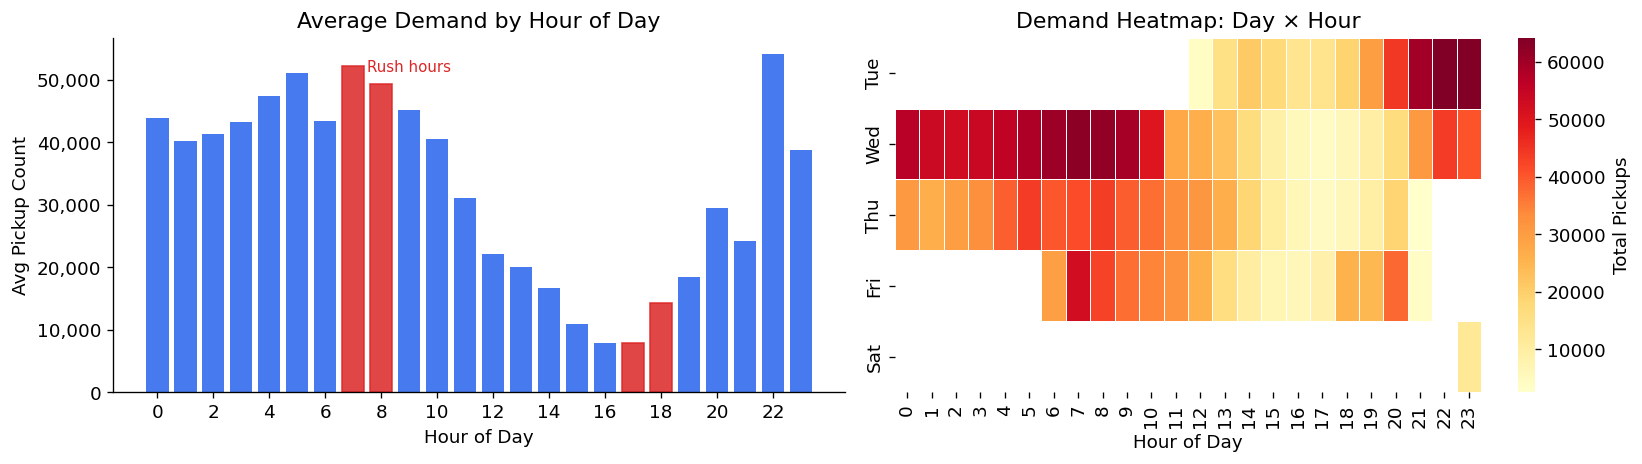

Saved: outputs/eda/01_hourly_demand.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: Average demand by hour ────────────────────────────
ax = axes[0]
bars = ax.bar(hourly_avg['hour'], hourly_avg['avg_pickups'], color=PALETTE[0], alpha=0.85)
# Highlight rush hours
for h in [7, 8, 17, 18]:
    if h < len(bars):
        bars[h].set_color(PALETTE[2])
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Pickup Count')
ax.set_title('Average Demand by Hour of Day')
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.text(7.5, hourly_avg['avg_pickups'].max() * 0.95, 'Rush hours', color=PALETTE[2], fontsize=9)

# ── Right: Heatmap hour × day-of-week ───────────────────────
ax = axes[1]
pivot = hourly_df.pivot_table(index='day_of_week', columns='hour_of_day',
                               values='total_pickups', aggfunc='sum')
day_names = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
pivot.index = [day_names.get(i, str(i)) for i in pivot.index]
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.0f',
            cbar_kws={'label': 'Total Pickups'}, linewidths=0.3)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
ax.set_title('Demand Heatmap: Day × Hour')

plt.tight_layout()
plt.savefig('outputs/eda/01_hourly_demand.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eda/01_hourly_demand.png')

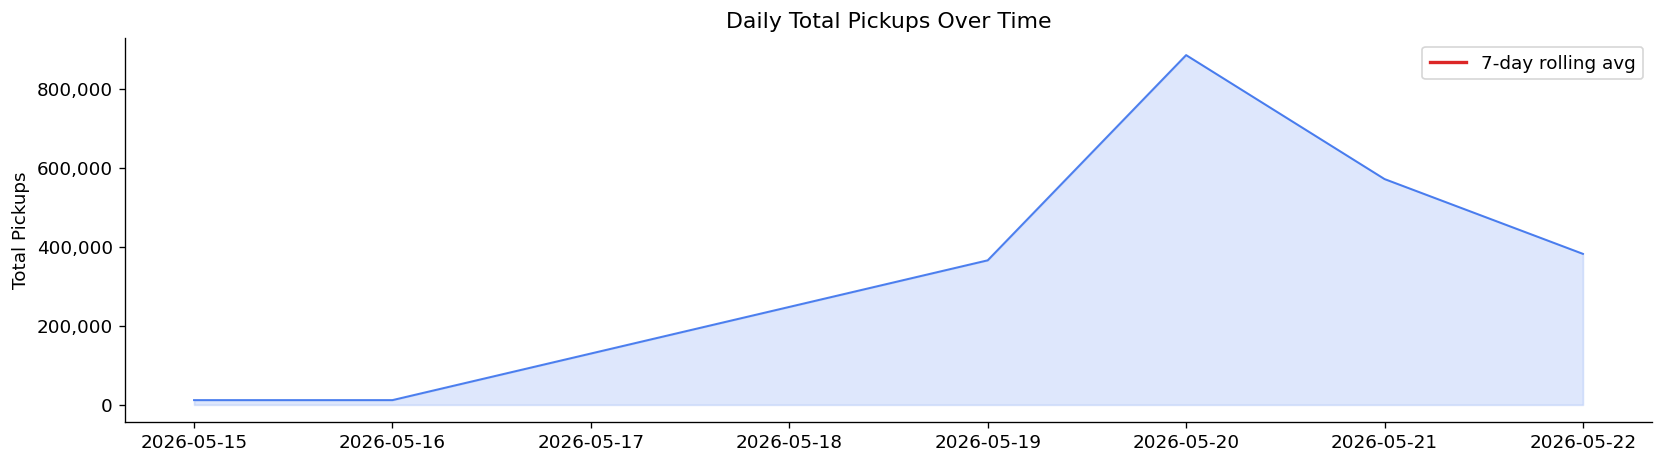

In [13]:
# Daily demand time-series (aggregate all zones)
daily_sql = """
SELECT
    time_bucket('1 day', time_bucket) AS day,
    SUM(pickup_count)                 AS total_pickups
FROM hourly_demand
GROUP BY 1
ORDER BY 1
"""
daily_df = pd.read_sql(daily_sql, engine, parse_dates=['day'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_df['day'], daily_df['total_pickups'], color=PALETTE[0], lw=1.2, alpha=0.8)
ax.fill_between(daily_df['day'], daily_df['total_pickups'], alpha=0.15, color=PALETTE[0])

# 7-day rolling average
rolling = daily_df['total_pickups'].rolling(7, center=True).mean()
ax.plot(daily_df['day'], rolling, color=PALETTE[2], lw=2, label='7-day rolling avg')

ax.set_title('Daily Total Pickups Over Time')
ax.set_xlabel('')
ax.set_ylabel('Total Pickups')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/eda/02_daily_demand.png', bbox_inches='tight')
plt.show()

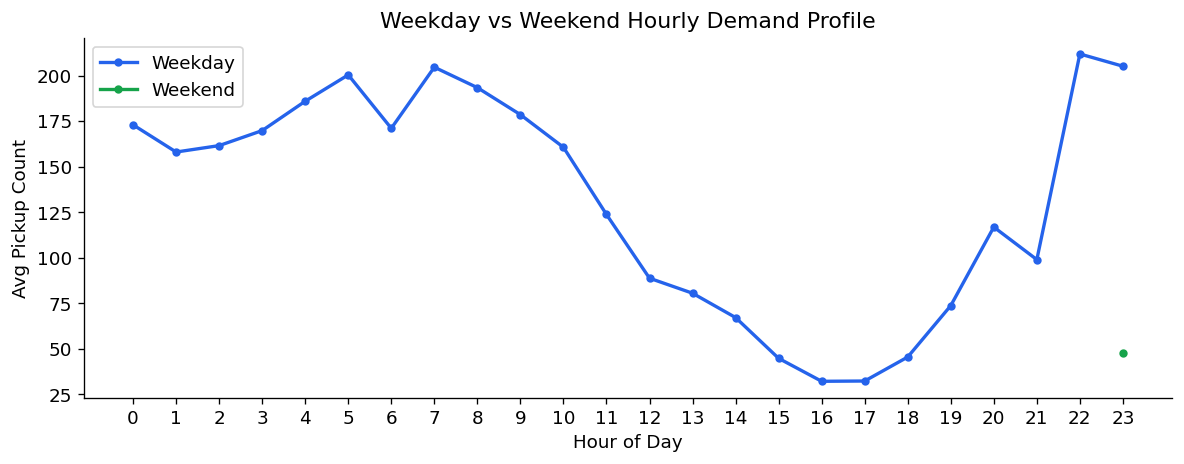

Weekday peak avg: 211.8  |  Weekend peak avg: 48.0
Weekend/Weekday peak ratio: 0.23


In [14]:
# Weekday vs Weekend demand profile
ww_sql = """
SELECT
    EXTRACT(HOUR FROM time_bucket)::int            AS hour,
    CASE WHEN EXTRACT(DOW FROM time_bucket) IN (0,6)
         THEN 'Weekend' ELSE 'Weekday' END         AS day_type,
    AVG(pickup_count)                              AS avg_pickups
FROM hourly_demand
GROUP BY 1, 2
ORDER BY 1
"""
ww_df = pd.read_sql(ww_sql, engine)

fig, ax = plt.subplots(figsize=(10, 4))
for dtype, color in [('Weekday', PALETTE[0]), ('Weekend', PALETTE[1])]:
    sub = ww_df[ww_df['day_type'] == dtype]
    ax.plot(sub['hour'], sub['avg_pickups'], label=dtype, color=color, lw=2, marker='o', ms=4)

ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Pickup Count')
ax.set_title('Weekday vs Weekend Hourly Demand Profile')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/eda/03_weekday_weekend.png', bbox_inches='tight')
plt.show()

# Finding
wd_peak = ww_df[(ww_df.day_type=='Weekday')]['avg_pickups'].max()
we_peak = ww_df[(ww_df.day_type=='Weekend')]['avg_pickups'].max()
print(f'Weekday peak avg: {wd_peak:,.1f}  |  Weekend peak avg: {we_peak:,.1f}')
print(f'Weekend/Weekday peak ratio: {we_peak/wd_peak:.2f}')

## 3 · Borough Comparison

In [15]:
borough_sql = """
SELECT
    z.borough,
    EXTRACT(HOUR FROM hd.time_bucket)::int    AS hour,
    SUM(hd.pickup_count)                      AS total_pickups,
    AVG(hd.pickup_count)                      AS avg_pickups
FROM hourly_demand hd
JOIN taxi_zones z ON z.zone_id = hd.zone_id
WHERE z.borough != 'Unknown'
GROUP BY 1, 2
ORDER BY 1, 2
"""
borough_df = pd.read_sql(borough_sql, engine)

# Total share per borough
share = borough_df.groupby('borough')['total_pickups'].sum().sort_values(ascending=False)
print('=== Borough Pickup Share ===')
for boro, cnt in share.items():
    print(f'  {boro:15s}: {cnt:12,.0f}  ({cnt/share.sum()*100:.1f}%)')

=== Borough Pickup Share ===
  Manhattan      :      863,431  (38.7%)
  Brooklyn       :      577,520  (25.9%)
  Queens         :      471,149  (21.1%)
  Bronx          :      284,521  (12.8%)
  Staten Island  :       32,955  (1.5%)


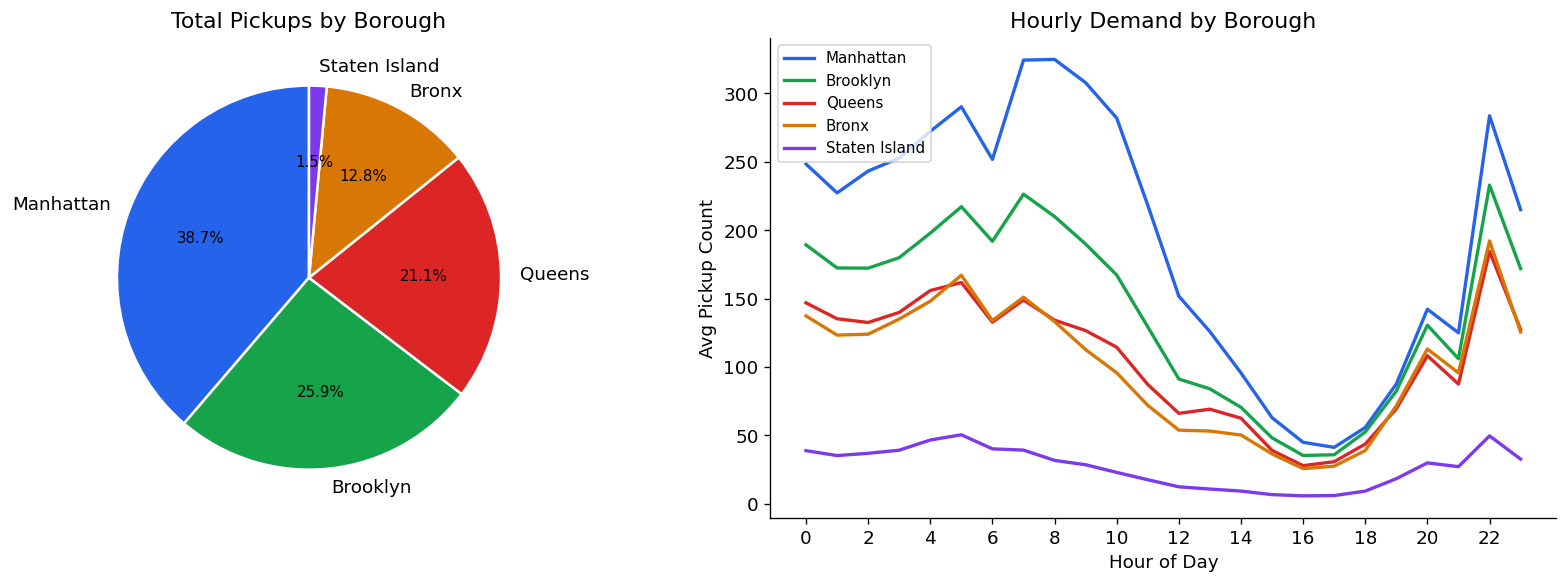

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Pie chart of total pickups by borough ──────────────
ax = axes[0]
colors = [BOROUGH_COLORS.get(b, '#999') for b in share.index]
wedges, texts, autotexts = ax.pie(
    share.values, labels=share.index, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Total Pickups by Borough')

# ── Right: Hourly demand curve per borough ───────────────────
ax = axes[1]
for boro in share.index:
    sub = borough_df[borough_df['borough'] == boro]
    ax.plot(sub['hour'], sub['avg_pickups'],
            label=boro, color=BOROUGH_COLORS.get(boro, '#999'), lw=2)

ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Pickup Count')
ax.set_title('Hourly Demand by Borough')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/eda/04_borough_comparison.png', bbox_inches='tight')
plt.show()

## 4 · Trip Characteristics

In [17]:
# Sample up to 500k trips for distribution plots (avoid OOM in Colab)
trip_sql = """
SELECT
    trip_miles,
    trip_time_min,
    hour_of_day,
    is_weekend,
    is_rush_hour
FROM trip_events
WHERE trip_miles > 0
  AND trip_miles < 50         -- remove extreme outliers
  AND trip_time_min > 0
  AND trip_time_min < 120
ORDER BY RANDOM()
LIMIT 500000
"""
trip_df = pd.read_sql(trip_sql, engine)
trip_df['speed_mph'] = (trip_df['trip_miles'] / (trip_df['trip_time_min'] / 60)).clip(0, 80)
print(f'Sampled {len(trip_df):,} trips for distribution analysis')
print(trip_df[['trip_miles','trip_time_min','speed_mph']].describe().round(2))

Sampled 500,000 trips for distribution analysis
       trip_miles  trip_time_min  speed_mph
count   500000.00      500000.00  500000.00
mean         4.79          18.84      13.58
std          5.31          13.26       7.23
min          0.01           0.02       0.07
25%          1.46           9.42       8.64
50%          2.78          15.28      11.45
75%          6.05          24.43      16.57
max         50.00         119.97      80.00


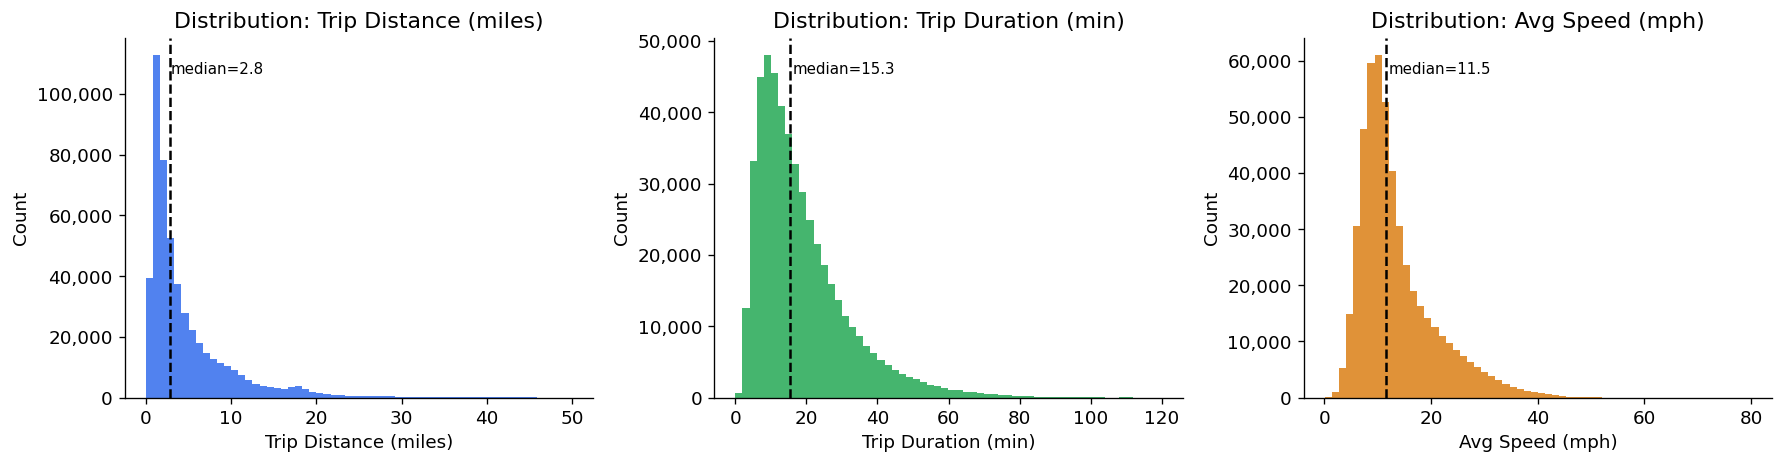

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in [
    (axes[0], 'trip_miles',    'Trip Distance (miles)', PALETTE[0]),
    (axes[1], 'trip_time_min', 'Trip Duration (min)',   PALETTE[1]),
    (axes[2], 'speed_mph',     'Avg Speed (mph)',       PALETTE[3]),
]:
    ax.hist(trip_df[col], bins=60, color=color, alpha=0.8, edgecolor='none')
    median = trip_df[col].median()
    ax.axvline(median, color='black', lw=1.5, linestyle='--')
    ax.text(median * 1.05, ax.get_ylim()[1] * 0.9, f'median={median:.1f}', fontsize=9)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution: {label}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('outputs/eda/05_trip_distributions.png', bbox_inches='tight')
plt.show()

=== Rush Hour vs Off-Peak Median Trip Stats ===
           trip_miles  trip_time_min  speed_mph
Off-peak         2.77          14.93      11.57
Rush hour        2.83          16.22      11.12


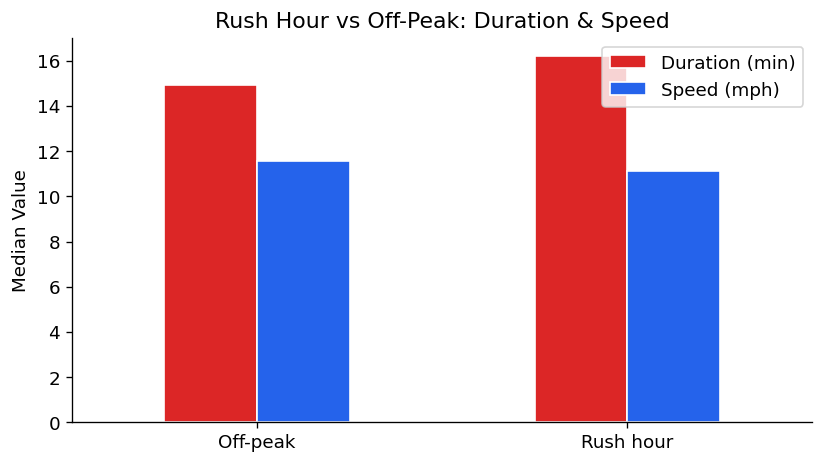

In [19]:
# Rush hour vs non-rush hour trip characteristics
rush_stats = trip_df.groupby('is_rush_hour')[['trip_miles','trip_time_min','speed_mph']].median()
rush_stats.index = ['Off-peak', 'Rush hour']
print('=== Rush Hour vs Off-Peak Median Trip Stats ===')
print(rush_stats.round(2))

# Visualize
rush_stats[['trip_time_min','speed_mph']].plot(kind='bar', figsize=(7,4),
    color=[PALETTE[2], PALETTE[0]], edgecolor='white', rot=0)
plt.title('Rush Hour vs Off-Peak: Duration & Speed')
plt.ylabel('Median Value')
plt.legend(['Duration (min)', 'Speed (mph)'])
plt.tight_layout()
plt.savefig('outputs/eda/06_rush_hour_comparison.png', bbox_inches='tight')
plt.show()

## 5 · Top Zones Analysis

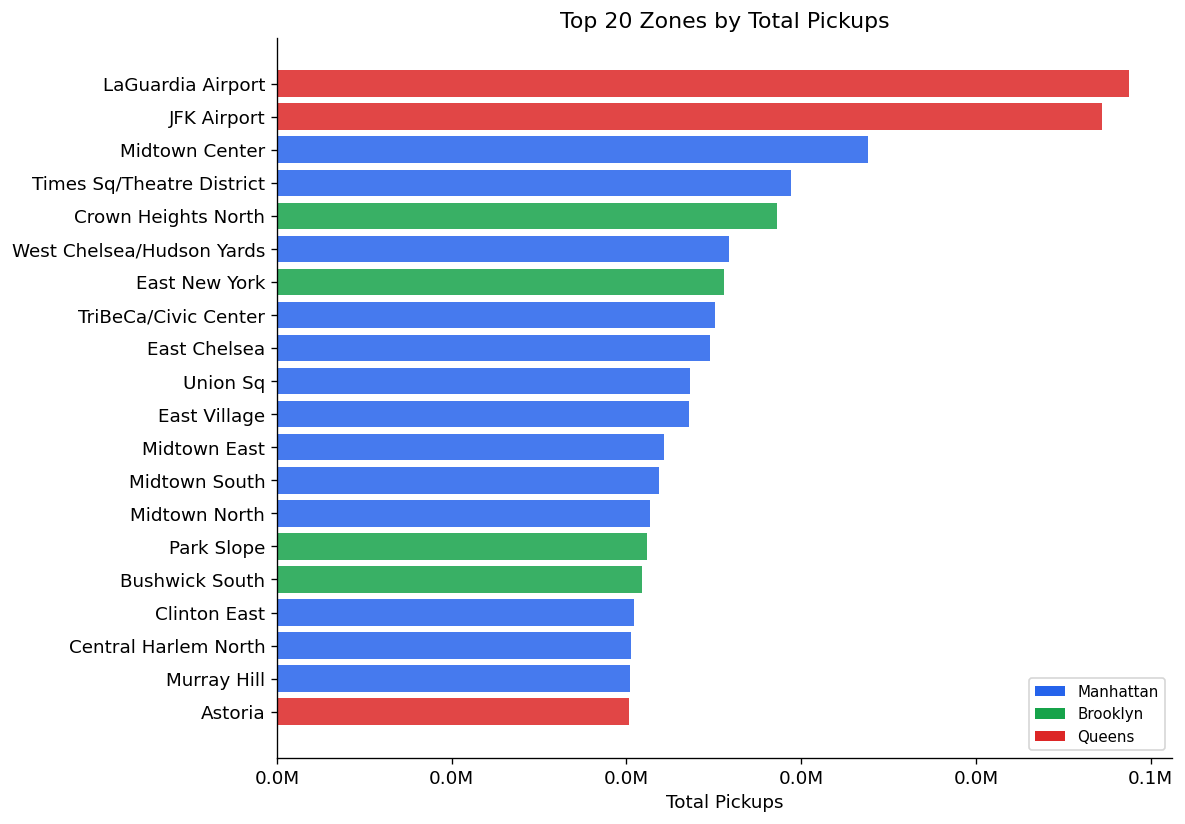


Top 5 zones:
                zone_name   borough  total_pickups
        LaGuardia Airport    Queens          48783
              JFK Airport    Queens          47239
           Midtown Center Manhattan          33829
Times Sq/Theatre District Manhattan          29425
      Crown Heights North  Brooklyn          28637


In [20]:
top_zones_sql = """
SELECT
    z.zone_name,
    z.borough,
    SUM(hd.pickup_count)    AS total_pickups,
    SUM(hd.dropoff_count)   AS total_dropoffs,
    AVG(hd.avg_trip_miles)  AS avg_miles
FROM hourly_demand hd
JOIN taxi_zones z ON z.zone_id = hd.zone_id
GROUP BY z.zone_id, z.zone_name, z.borough
ORDER BY total_pickups DESC
LIMIT 20
"""
top_df = pd.read_sql(top_zones_sql, engine)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [BOROUGH_COLORS.get(b, '#999') for b in top_df['borough']]
bars = ax.barh(top_df['zone_name'], top_df['total_pickups'], color=colors, alpha=0.85)
ax.set_xlabel('Total Pickups')
ax.set_title('Top 20 Zones by Total Pickups')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.invert_yaxis()

# Borough legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b) for b, c in BOROUGH_COLORS.items() if b in top_df['borough'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/eda/07_top_zones.png', bbox_inches='tight')
plt.show()

print('\nTop 5 zones:')
print(top_df[['zone_name','borough','total_pickups']].head(5).to_string(index=False))

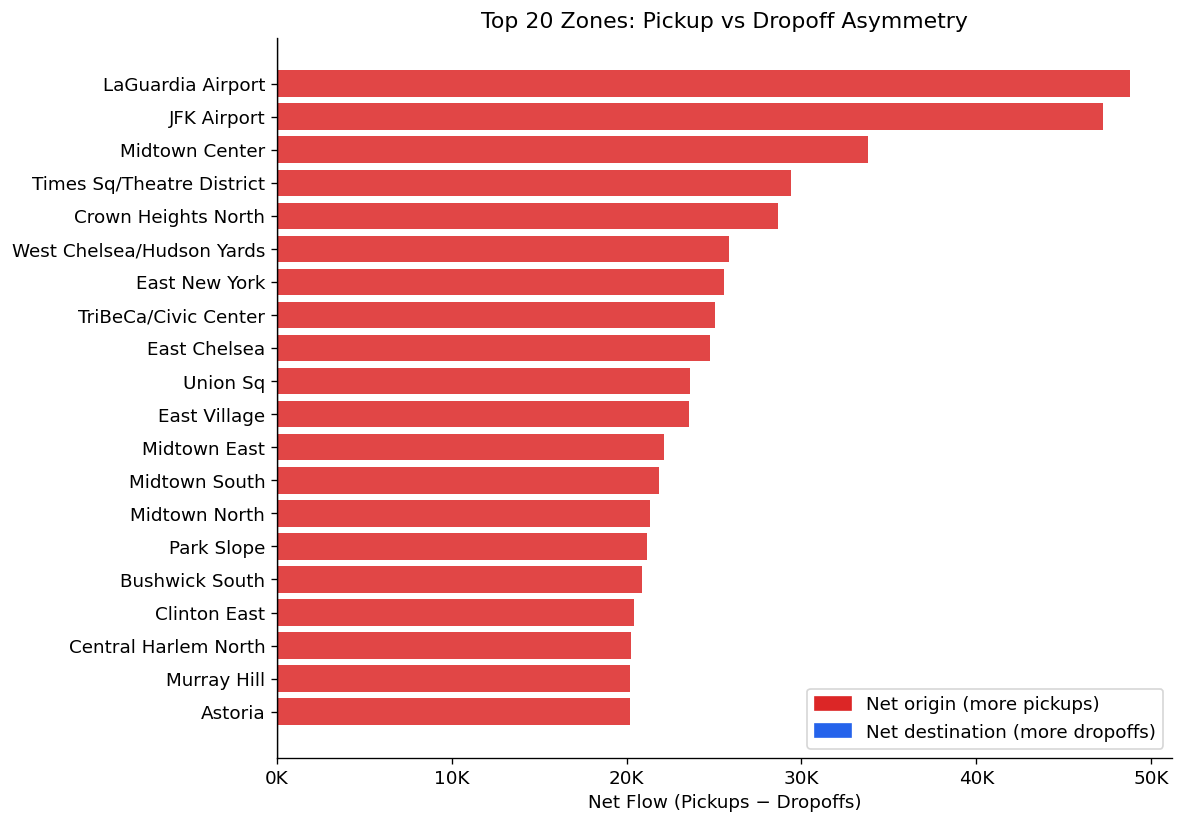

In [21]:
# Pickup vs dropoff asymmetry (net flow indicator)
top_df['net_flow'] = top_df['total_pickups'] - top_df['total_dropoffs']
top_df_sorted = top_df.sort_values('net_flow')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DC2626' if v > 0 else '#2563EB' for v in top_df_sorted['net_flow']]
ax.barh(top_df_sorted['zone_name'], top_df_sorted['net_flow'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Net Flow (Pickups − Dropoffs)')
ax.set_title('Top 20 Zones: Pickup vs Dropoff Asymmetry')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#DC2626', label='Net origin (more pickups)'),
                   Patch(color='#2563EB', label='Net destination (more dropoffs)')])
plt.tight_layout()
plt.savefig('outputs/eda/08_net_flow.png', bbox_inches='tight')
plt.show()

## 6 · Weather–Demand Correlation

In [31]:
weather_sql = """
SELECT
    time_bucket('1 hour', hd.time_bucket)   AS hour,
    SUM(hd.pickup_count)                    AS total_pickups,
    AVG(hd.avg_temperature)                 AS temperature_c,
    AVG(hd.precipitation_mm)                AS precipitation_mm
FROM hourly_demand hd
WHERE hd.avg_temperature IS NOT NULL
GROUP BY 1
ORDER BY 1
"""
weather_df = pd.read_sql(weather_sql, engine, parse_dates=['hour'])
print(f'Rows with weather data: {len(weather_df):,}')

HAS_WEATHER = len(weather_df) > 10 and weather_df['temperature_c'].notna().sum() > 10

if HAS_WEATHER:
    corr_temp = weather_df['total_pickups'].corr(weather_df['temperature_c'])
    corr_rain = weather_df['total_pickups'].corr(weather_df['precipitation_mm'])
    print(f'Pearson r (pickups vs temperature):    {corr_temp:.3f}')
    print(f'Pearson r (pickups vs precipitation):  {corr_rain:.3f}')
else:
    corr_temp = corr_rain = float('nan')
    print('Skipping weather correlation — no weather data joined to hourly_demand.')
    print('(Weather enrichment requires Spark Block 3: enrichment_weather.py)')

Rows with weather data: 76
Pearson r (pickups vs temperature):    -0.489
Pearson r (pickups vs precipitation):  -0.471


In [32]:
print(f'weather_df rows: {len(weather_df)}')
print(f'rows with temperature: {weather_df["temperature_c"].notna().sum()}')
print(f'rows with precipitation: {weather_df["precipitation_mm"].notna().sum()}')

weather_df rows: 76
rows with temperature: 76
rows with precipitation: 15


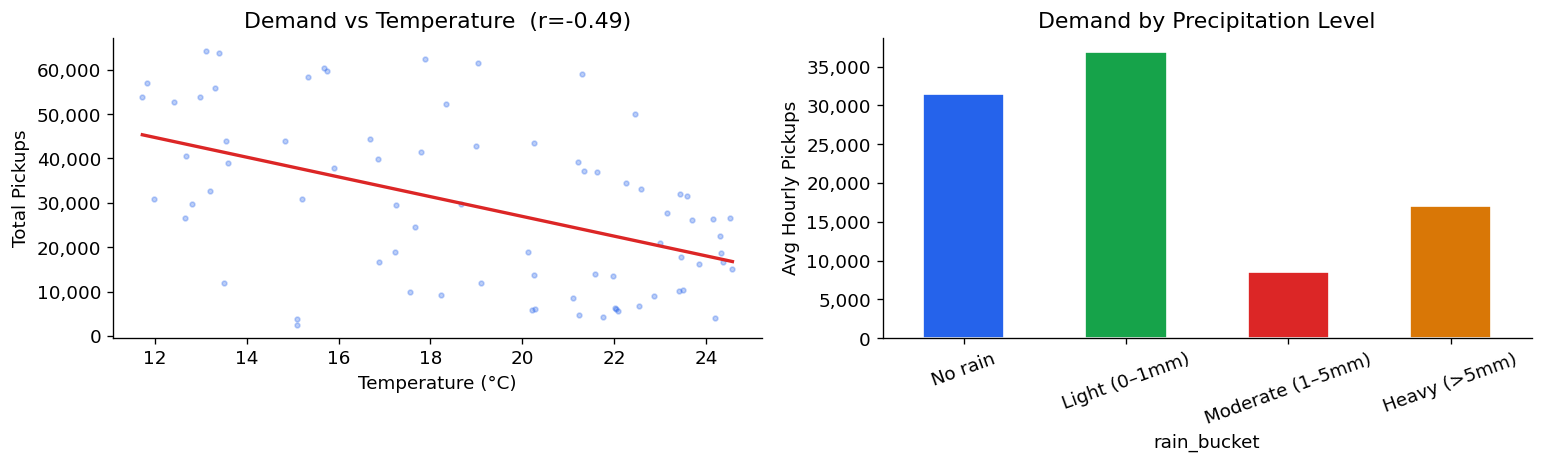

In [33]:
if HAS_WEATHER:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.scatter(weather_df['temperature_c'], weather_df['total_pickups'],
               alpha=0.3, s=8, color=PALETTE[0])
    mask = weather_df['temperature_c'].notna() & weather_df['total_pickups'].notna()
    z = np.polyfit(weather_df.loc[mask, 'temperature_c'],
                   weather_df.loc[mask, 'total_pickups'], 1)
    x_line = np.linspace(weather_df['temperature_c'].min(),
                         weather_df['temperature_c'].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color=PALETTE[2], lw=2)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Total Pickups')
    ax.set_title(f'Demand vs Temperature  (r={corr_temp:.2f})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    ax = axes[1]
    weather_df['rain_bucket'] = pd.cut(
        weather_df['precipitation_mm'].fillna(0),
        bins=[-0.01, 0, 1, 5, 100],
        labels=['No rain', 'Light (0–1mm)', 'Moderate (1–5mm)', 'Heavy (>5mm)']
    )
    rain_avg = weather_df.groupby('rain_bucket', observed=True)['total_pickups'].mean()
    rain_avg.plot(kind='bar', ax=ax, color=PALETTE[:4], edgecolor='white', rot=20)
    ax.set_ylabel('Avg Hourly Pickups')
    ax.set_title('Demand by Precipitation Level')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.savefig('outputs/eda/09_weather_correlation.png', bbox_inches='tight')
    plt.show()
else:
    print('Skipped 09_weather_correlation.png')

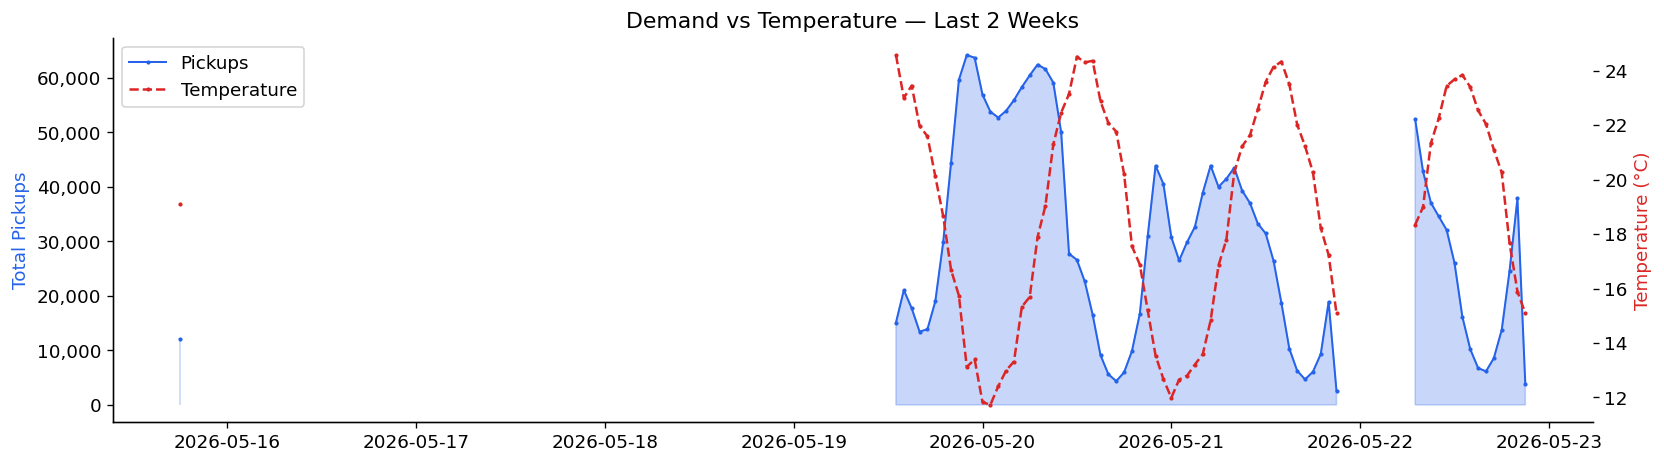

In [35]:
if HAS_WEATHER:
    sample = weather_df.tail(14 * 24).copy()

    # Detect time gaps > 1.5h and break the line by inserting NaN
    sample = sample.sort_values('hour').reset_index(drop=True)
    sample['gap'] = sample['hour'].diff().dt.total_seconds() / 3600 > 1.5
    sample.loc[sample['gap'], 'total_pickups'] = np.nan
    sample.loc[sample['gap'], 'temperature_c'] = np.nan

    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()

    ax1.fill_between(sample['hour'], sample['total_pickups'],
                     alpha=0.25, color=PALETTE[0])
    ax1.plot(sample['hour'], sample['total_pickups'], color=PALETTE[0], lw=1.2,
             marker='.', markersize=3, label='Pickups')
    ax2.plot(sample['hour'], sample['temperature_c'], color=PALETTE[2], lw=1.5,
             linestyle='--', marker='.', markersize=3, label='Temperature')

    ax1.set_ylabel('Total Pickups', color=PALETTE[0])
    ax2.set_ylabel('Temperature (°C)', color=PALETTE[2])
    ax1.set_title('Demand vs Temperature — Last 2 Weeks')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.savefig('outputs/eda/10_demand_temperature_timeseries.png', bbox_inches='tight')
    plt.show()
else:
    print('Skipped 10_demand_temperature_timeseries.png')

## 7 · Summary Findings

In [26]:
print('=' * 60)
print('EDA SUMMARY FINDINGS')
print('=' * 60)

# Re-compute key stats for summary
peak_hour    = int(hourly_avg.loc[hourly_avg.avg_pickups.idxmax(), 'hour'])
trough_hour  = int(hourly_avg.loc[hourly_avg.avg_pickups.idxmin(), 'hour'])
peak_val     = hourly_avg['avg_pickups'].max()
trough_val   = hourly_avg['avg_pickups'].min()
top_borough  = share.index[0]
top_boro_pct = share.iloc[0] / share.sum() * 100

findings = [
    f'1. TEMPORAL: Peak demand at {peak_hour:02d}:00 ({peak_val:,.0f} avg pickups/hr), '
    f'   trough at {trough_hour:02d}:00 ({trough_val:,.0f}). Peak-to-trough ratio: {peak_val/trough_val:.1f}x',
    f'2. WEEKDAY vs WEEKEND: Weekend peak ratio vs weekday: {we_peak/wd_peak:.2f}x '
    f'   (weekend demand peaks later, around midnight)',
    f'3. BOROUGH: {top_borough} dominates with {top_boro_pct:.1f}% of total pickups',
    f'4. TRIP DISTANCE: Median {trip_df["trip_miles"].median():.1f} miles, '
    f'   median duration {trip_df["trip_time_min"].median():.0f} min',
    f'5. WEATHER: Demand correlation with temperature r={corr_temp:.2f}, '
    f'   precipitation r={corr_rain:.2f}',
]

for f in findings:
    print()
    print(f)

print()
print('Output charts saved to: outputs/eda/')

EDA SUMMARY FINDINGS

1. TEMPORAL: Peak demand at 22:00 (54,016 avg pickups/hr),    trough at 16:00 (7,860). Peak-to-trough ratio: 6.9x

2. WEEKDAY vs WEEKEND: Weekend peak ratio vs weekday: 0.23x    (weekend demand peaks later, around midnight)

3. BOROUGH: Manhattan dominates with 38.7% of total pickups

4. TRIP DISTANCE: Median 2.8 miles,    median duration 15 min

5. WEATHER: Demand correlation with temperature r=nan,    precipitation r=nan

Output charts saved to: outputs/eda/


In [36]:
# Sync outputs to Drive
import os, shutil
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=False)

DRIVE_OUTPUTS = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs'
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

n = 0
for root, _, files_ in os.walk('outputs'):
    for f in files_:
        src = os.path.join(root, f)
        rel = os.path.relpath(src, 'outputs')
        dst = os.path.join(DRIVE_OUTPUTS, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        n += 1

print(f'Synced {n} files to {DRIVE_OUTPUTS}')

Synced 10 files to /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs
